In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

GROUP 17 -- 2301me05 (aman) , 2301me45(sanit) , 2301me47(sparsh)

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
# ADD GlobalAveragePooling2D to this list
from tensorflow.keras.layers import Dense, Flatten, BatchNormalization, Dropout, Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
# --- Part 1 & 3: Data Loading, Preprocessing, and Augmentation ---


from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# --- 1. Define Image Parameters ---
IMG_HEIGHT = 200
IMG_WIDTH = 200
BATCH_SIZE = 16

# --- 2. Define Paths (Corrected based on your image) ---
base_dir = '/kaggle/input/metal-surface-defects-data/Metal Surface Defects Data' 

train_dir = os.path.join(base_dir, 'train')
# We will NOT use the original valid_dir
test_dir = os.path.join(base_dir, 'test') 

# --- 3. Create Generator for Training (with Data Augmentation AND Validation Split) ---
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values
    rotation_range=20,       
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # <-- THIS IS THE FIX: Will hold out 20% of data for validation
)

# --- 4. Create Generator for Testing (NO Augmentation) ---
test_datagen = ImageDataGenerator(rescale=1./255)

# --- 5. Flow Data from Directories ---
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale',
    subset='training'  
)


val_gen = train_datagen.flow_from_directory(
    train_dir, # <-- Point to the SAME train_dir
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale', 
    subset='validation', 
    shuffle=False
)

# Test generator remains the same
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale', 
    shuffle=False
)

# Print the class indices to confirm they loaded
print(f"Class indices found: {train_gen.class_indices}")

Found 1326 images belonging to 6 classes.
Found 330 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Class indices found: {'Crazing': 0, 'Inclusion': 1, 'Patches': 2, 'Pitted': 3, 'Rolled': 4, 'Scratches': 5}


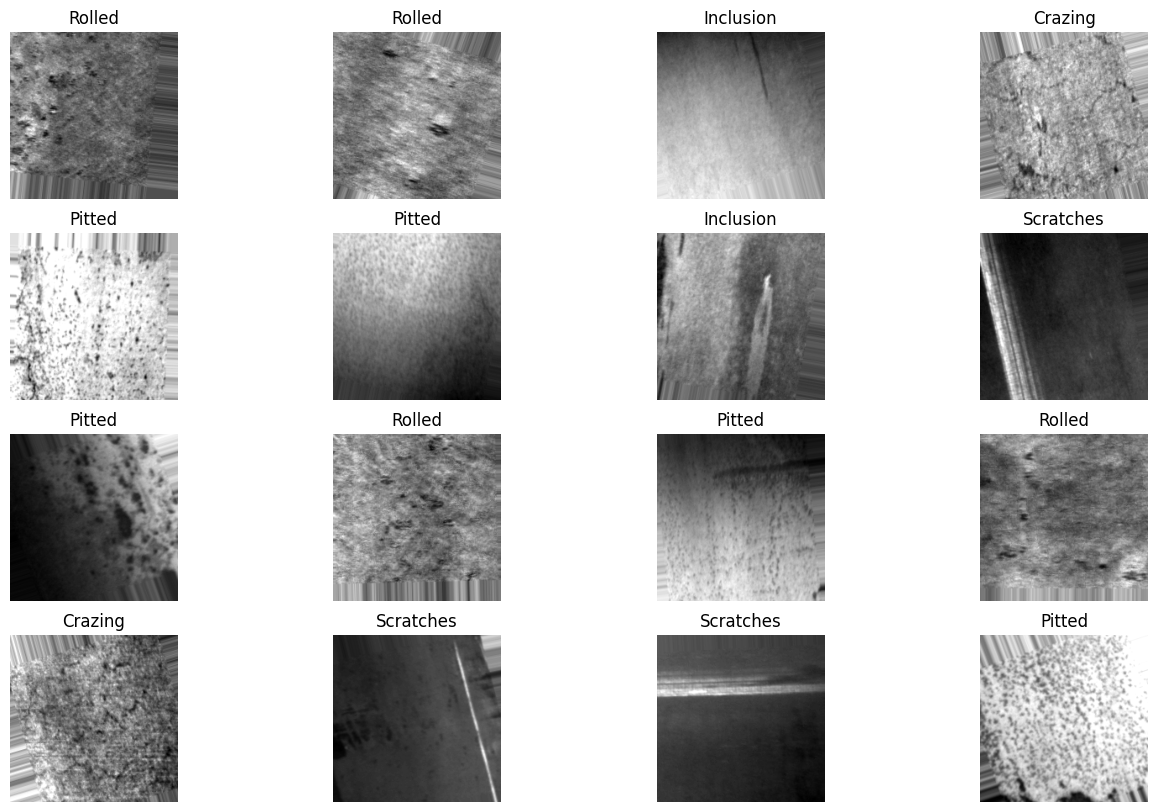

In [27]:
# --- Part 1: Visualize Sample Images ---
# [20] Visualize a batch of training images to understand the data.
images, labels = next(train_gen)

plt.figure(figsize=(16, 10))
class_names = list(train_gen.class_indices.keys())

for i in range(16):  # Display 16 images from the batch
    ax = plt.subplot(4, 4, i + 1)
    # Images are grayscale (1 channel), so we squeeze the last dimension
    plt.imshow(np.squeeze(images[i]), cmap='gray')
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")


plt.show()

In [6]:
# --- Part 2 & 3: Build Improved CNN Model ---

# A more modern and efficient version of your CNN
model = Sequential([
    # Input shape (200, 200, 1)
    Conv2D(64, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 1)),
    BatchNormalization(), 
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(), 
    MaxPooling2D((2, 2)),
    
    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(), 
    MaxPooling2D((2, 2)),

    # --- THIS IS THE FIX ---
    # GlobalAveragePooling2D is much better than Flatten() for reducing parameters
    # It replaces Flatten() and the first big Dense(256) layer.
    GlobalAveragePooling2D(),
    # -------------------------
    
    Dropout(0.5), # Add dropout for regularization
    
    # Output Layer
    Dense(6, activation='softmax')
])

# We can use a slightly faster learning rate now
model.compile(optimizer=Adam(learning_rate=0.001), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()

I0000 00:00:1762255160.551402    3524 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1762255160.552126    3524 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 198, 198, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 198, 198, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 99, 99, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 97, 97, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 97, 97, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 46, 46, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 46, 46, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 23, 23, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 372,998 (1.42 MB)

 Trainable params: 372,102 (1.42 MB)

 Non-trainable params: 896 (3.50 KB)

In [7]:
# --- Part 4: Train the Model ---
# Train the model for more epochs
history = model.fit(
    train_gen,
    epochs=60,  
    validation_data=val_gen 
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60


I0000 00:00:1762255870.914321    3617 service.cc:148] XLA service 0x7d3554051cf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762255870.914356    3617 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1762255870.914362    3617 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1762255871.245875    3617 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/83 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.1562 - loss: 2.5910 

I0000 00:00:1762255876.635573    3617 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


83/83 ━━━━━━━━━━━━━━━━━━━━ 26s 204ms/step - accuracy: 0.4892 - loss: 1.4660 - val_accuracy: 0.1667 - val_loss: 2.1651
Epoch 2/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.6867 - loss: 0.8212 - val_accuracy: 0.3333 - val_loss: 2.6972
Epoch 3/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.7780 - loss: 0.6246 - val_accuracy: 0.1667 - val_loss: 3.6510
Epoch 4/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 0.7820 - loss: 0.5609 - val_accuracy: 0.3333 - val_loss: 3.2685
Epoch 5/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.8724 - loss: 0.3704 - val_accuracy: 0.3121 - val_loss: 2.7050
Epoch 6/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 0.8739 - loss: 0.3218 - val_accuracy: 0.3333 - val_loss: 4.1155
Epoch 7/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.8908 - loss: 0.3112 - val_accuracy: 0.4182 - val_loss: 4.9837
Epoch 8/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 0.9014 - loss: 0.2665 - val_accuracy: 0.3697 - val_loss: 

In [8]:
# --- Part 4: Final Test Evaluation ---
model.evaluate(test_gen)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 284ms/step - accuracy: 0.8753 - loss: 0.3817


[0.5082058310508728, 0.8055555820465088]

--- 🎯 Final Model Accuracy ---
Final Training Accuracy (from epoch 10): 98.64%
Final Test Accuracy (from epoch 10):   89.09%


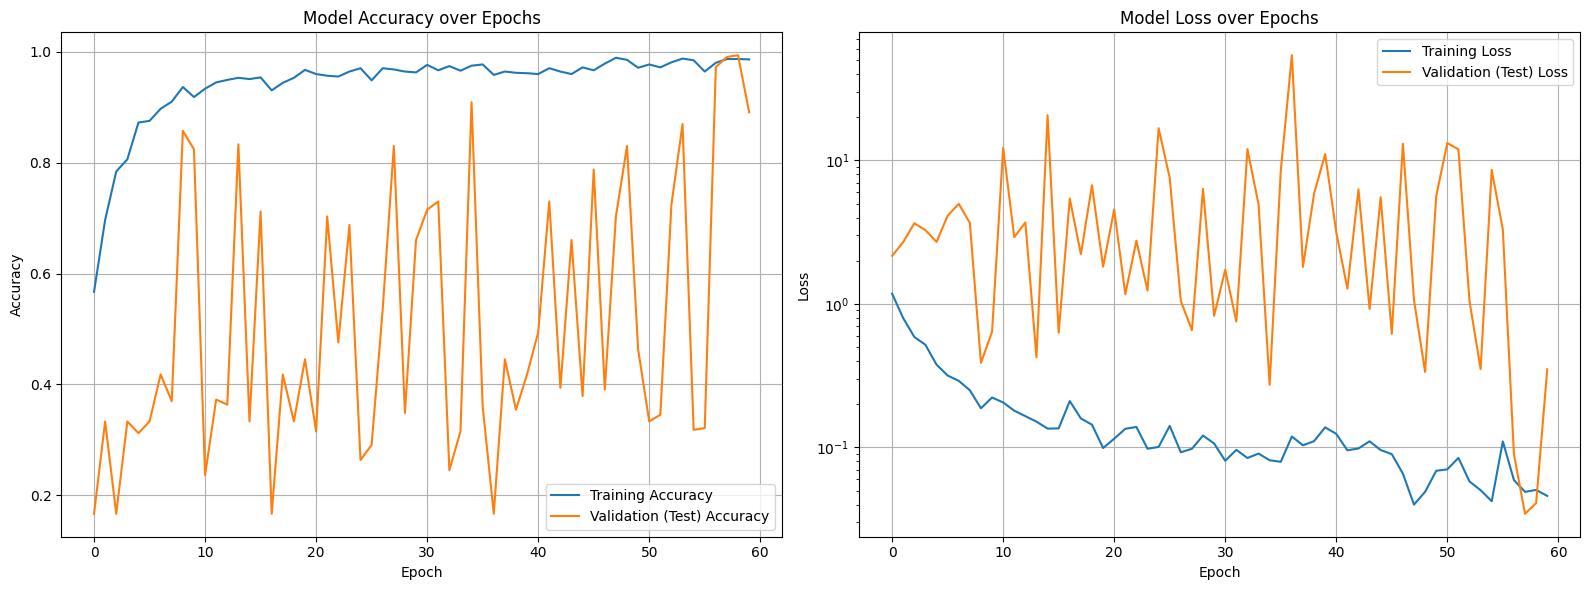

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step

--- 📊 Classification Report ---
              precision    recall  f1-score   support

     Crazing       1.00      1.00      1.00        12
   Inclusion       0.86      1.00      0.92        12
     Patches       0.55      1.00      0.71        12
      Pitted       1.00      0.25      0.40        12
      Rolled       0.86      1.00      0.92        12
   Scratches       1.00      0.58      0.74        12

    accuracy                           0.81        72
   macro avg       0.88      0.81      0.78        72
weighted avg       0.88      0.81      0.78        72


--- 🔢 Confusion Matrix ---
[[12  0  0  0  0  0]
 [ 0 12  0  0  0  0]
 [ 0  0 12  0  0  0]
 [ 0  2  5  3  2  0]
 [ 0  0  0  0 12  0]
 [ 0  0  5  0  0  7]]


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. Print Final Accuracy ---
final_train_acc = history.history['accuracy'][-1]
final_test_acc = history.history['val_accuracy'][-1]

print("--- 🎯 Final Model Accuracy ---")
print(f"Final Training Accuracy (from epoch 10): {final_train_acc * 100:.2f}%")
print(f"Final Test Accuracy (from epoch 10):   {final_test_acc * 100:.2f}%")


# --- 2. Plot Training History ---
plt.figure(figsize=(16, 6))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation (Test) Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation (Test) Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.yscale('log')

plt.tight_layout()
plt.savefig('training_history_plots.png')
plt.show()


# --- 3. Get Detailed Evaluation Metrics (Report & Matrix) ---
classes = list(train_gen.class_indices.keys())

test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = test_gen.classes

# Print Classification Report
print("\n--- 📊 Classification Report ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=classes))

# Print Confusion Matrix
print("\n--- 🔢 Confusion Matrix ---")
print(confusion_matrix(y_true_classes, y_pred_classes))

In [10]:
model.save('/kaggle/working/intel_image.keras')

In [11]:
import zipfile

with zipfile.ZipFile('/kaggle/working/intel_image.zip', 'w') as zipf:
    zipf.write('/kaggle/working/intel_image.keras', arcname='intel_image.keras')

print("✅ Model saved and zipped successfully!")

✅ Model saved and zipped successfully!


In [12]:
my_model=tf.keras.models.load_model('intel_image.keras')

In [16]:
# Example path to a test image from the new dataset. You can change this.
img_path='/kaggle/input/metal-surface-defects-data/Metal Surface Defects Data/test/Crazing/Cr_1.bmp'

In [17]:
from PIL import Image

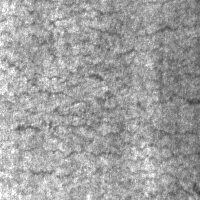

In [18]:
img=Image.open(img_path)
img

In [19]:
from PIL import Image
import numpy as np

img = Image.open(img_path)
img = img.convert("L")             # <-- CRITICAL: Convert to Grayscale ("L")
img = img.resize((IMG_HEIGHT, IMG_WIDTH)) # <-- CRITICAL: Resize to 200x200
img = np.asarray(img)
img = img / 255.0                  # <-- Add rescale (normalization)

# Reshape to (1, 200, 200, 1)
img = np.expand_dims(img, axis=0)  # Add batch dimension
img = np.expand_dims(img, axis=-1) # <-- CRITICAL: Add channel dimension (1)

In [20]:
img.shape

(1, 200, 200, 1)

In [21]:
pred=my_model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 811ms/step


In [22]:
pred[0]

array([9.9962771e-01, 6.0967885e-18, 3.7222332e-04, 6.2081996e-17,
       8.7958727e-17, 2.3103701e-11], dtype=float32)

In [23]:
index=np.argmax(pred[0])
index

0

In [24]:
train_gen.class_indices

{'Crazing': 0,
 'Inclusion': 1,
 'Patches': 2,
 'Pitted': 3,
 'Rolled': 4,
 'Scratches': 5}

In [25]:
# Get the class names dynamically from the generator
class_names = list(train_gen.class_indices.keys())
            
# Print the predicted class name
print(f"Predicted Class: {class_names[index]}")

Predicted Class: Crazing
